# F1 Lap Time Prediction — Exploratory Data Analysis

This notebook explores the dataset collected in notebook 01:  
**5 races from the 2023 F1 season** — Bahrain, Saudi Arabia, Australia, Azerbaijan, Monaco.

Goal: understand the structure of the data, spot patterns and relationships,  
and decide which features deserve attention in the modelling step.

**Input:** `data/raw/laps_2023.csv`  
**Output:** `outputs/figures/` (6 PNG charts)

---
## 1. Imports & Load Data

We load the cleaned CSV produced by notebook 01 and do a quick sanity check  
on shape and first rows before any analysis.

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

DATA_PATH    = '../data/raw/laps_2023.csv'
FIGURES_PATH = '../outputs/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
display(df.head())

Shape: 4032 rows × 8 columns


,LapTime,LapNumber,Stint,TyreLife,Compound,Driver,Team,GrandPrix
0,98.006,3.0,1.0,6.0,SOFT,VER,Red Bull Racing,Bahrain
1,97.976,4.0,1.0,7.0,SOFT,VER,Red Bull Racing,Bahrain
2,98.035,5.0,1.0,8.0,SOFT,VER,Red Bull Racing,Bahrain
3,97.986,6.0,1.0,9.0,SOFT,VER,Red Bull Racing,Bahrain
4,98.021,7.0,1.0,10.0,SOFT,VER,Red Bull Racing,Bahrain


---
## 2. Data Overview

Before plotting anything, we check data types, null counts, and the distribution  
of categorical columns. This tells us if any cleaning is still needed and gives  
a first sense of class balance (e.g. how many laps per compound or per driver).

In [3]:
# --- Types and nulls ---
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulls':   df.isnull().sum(),
    'null_%':  (df.isnull().sum() / len(df) * 100).round(2),
    'unique':  df.nunique(),
})
print('--- Column summary ---')
display(info)

# --- Categorical value counts ---
for col in ['GrandPrix', 'Compound', 'Team', 'Driver']:
    print(f'\n--- {col} ---')
    display(df[col].value_counts().rename('count').to_frame())

--- Column summary ---


,dtype,nulls,null_%,unique
LapTime,float64,0,0.0,3653
LapNumber,float64,0,0.0,57
Stint,float64,0,0.0,6
TyreLife,float64,0,0.0,52
Compound,object,0,0.0,3
Driver,object,0,0.0,20
Team,object,0,0.0,10
GrandPrix,object,0,0.0,5



--- GrandPrix ---


,count
GrandPrix,
Monaco,893
Saudi Arabia,812
Bahrain,802
Azerbaijan,793
Australia,732



--- Compound ---


,count
Compound,
HARD,2827
MEDIUM,847
SOFT,358



--- Team ---


,count
Team,
Red Bull Racing,450
Aston Martin,417
Mercedes,417
Haas F1 Team,416
Alpine,415
Alfa Romeo,400
Ferrari,396
AlphaTauri,393
McLaren,380



--- Driver ---


,count
Driver,
ALO,228
VER,227
SAI,227
HAM,226
PER,223
TSU,219
GAS,214
MAG,209
NOR,208


---
## 3. Lap Time Distribution

Two views of the target variable:
- **Histogram:** overall shape — is LapTime roughly normal? Are there outliers?
- **Boxplot per Grand Prix:** each track has a different baseline lap time  
  (Monaco ~76 s, Bahrain ~95 s), which the model must learn to separate.

> **Interactive plot:** Use the dropdown below to filter the histogram by Grand Prix.  
> "All Races" shows the full five-race distribution; selecting a specific race isolates  
> that circuit's lap time profile, making outliers and shape differences easier to spot.

In [4]:
import ipywidgets as widgets

# ── Interactive histogram ──────────────────────────────────────────────────────
races_opts = ['All Races'] + sorted(df['GrandPrix'].unique().tolist())
dropdown = widgets.Dropdown(
    options=races_opts,
    value='All Races',
    description='Grand Prix:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px'),
)

def plot_histogram(grand_prix):
    data  = df if grand_prix == 'All Races' else df[df['GrandPrix'] == grand_prix]
    title = f'Lap Time Distribution — {grand_prix}  (n={len(data):,} laps)'

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(data['LapTime'], bins=min(60, max(10, len(data) // 10)),
                 kde=True, ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Lap Time (s)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

widgets.interact(plot_histogram, grand_prix=dropdown)

# ── Static boxplot per Grand Prix (saved to file) ─────────────────────────────
gp_order = df.groupby('GrandPrix')['LapTime'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='GrandPrix', y='LapTime', order=gp_order,
            ax=ax, linewidth=0.8)
ax.set_title('Lap Time by Grand Prix')
ax.set_xlabel('')
ax.set_ylabel('Lap Time (s)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}01_laptime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_laptime_distribution.png')

interactive(children=(Dropdown(description='Grand Prix:', layout=Layout(width='280px'), options=('All Races', …

Saved: 01_laptime_distribution.png


---
## 4. Tyre Compound Effect

Tyre compound is one of the most important features for lap time prediction.  
SOFT tyres offer more grip → lower lap times, but degrade faster.  
HARD tyres last longer but are slower.

The aggregate boxplot quantifies this gap across all five races.

> **Monaco distorts the aggregate view.** Monaco has naturally faster lap times (~76 s vs ~95 s at Bahrain)  
> and most drivers ran MEDIUM and HARD compounds with very short SOFT stints.  
> In the aggregate, this pulls MEDIUM lap times down — not because the compound is faster,  
> but because Monaco's shorter track inflates the MEDIUM sample with inherently quick laps.  
> The per-race breakdown below isolates each circuit's compound picture.

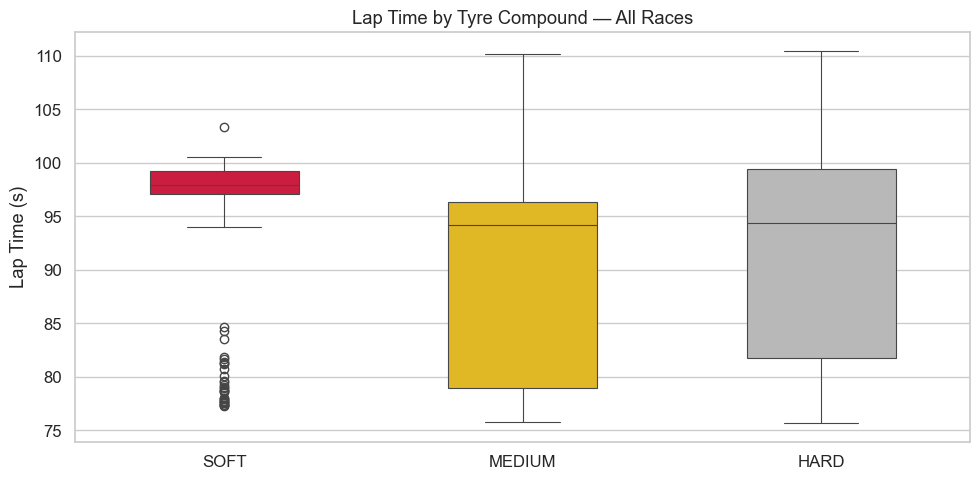

Saved: 02_compound_laptime.png

Mean lap time per compound (seconds):
Compound
SOFT      96.57
MEDIUM    90.14
HARD      92.19

Fastest compound on average: MEDIUM (90.14s)
Saved: 02b_compound_by_race.png


interactive(children=(Dropdown(description='Grand Prix:', layout=Layout(width='280px'), options=('All Races', …

<function __main__.plot_compound_interactive(grand_prix)>

In [5]:
# Canonical compound order and official F1 colours
COMPOUND_ORDER = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
COMPOUND_PALETTE = {
    'SOFT':         '#E8002D',  # red
    'MEDIUM':       '#FFC906',  # yellow (darkened for visibility on white bg)
    'HARD':         '#B8B8B8',  # grey  (white is invisible on white bg)
    'INTERMEDIATE': '#39B54A',  # green
    'WET':          '#0067FF',  # blue
}
present    = [c for c in COMPOUND_ORDER if c in df['Compound'].unique()]
races_list = sorted(df['GrandPrix'].unique())

# ── Aggregate boxplot (saved to PNG — used by README) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x='Compound', y='LapTime',
    order=present, palette=COMPOUND_PALETTE,
    ax=ax, linewidth=0.8, width=0.5,
)
ax.set_title('Lap Time by Tyre Compound — All Races')
ax.set_xlabel('')
ax.set_ylabel('Lap Time (s)')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}02_compound_laptime.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_compound_laptime.png')

means = df.groupby('Compound')['LapTime'].mean().reindex(present).round(2)
print(f'\nMean lap time per compound (seconds):\n{means.to_string()}')
print(f'\nFastest compound on average: {means.idxmin()} ({means.min():.2f}s)')

# ── Per-race static subplot (saved to PNG — used by README, not displayed) ─────
fig, axes_pg = plt.subplots(1, len(races_list), figsize=(18, 5), sharey=False)
fig.suptitle('Lap Time by Compound — Per Grand Prix', fontsize=13)

for ax, race in zip(axes_pg, races_list):
    subset     = df[df['GrandPrix'] == race]
    race_comps = [c for c in COMPOUND_ORDER if c in subset['Compound'].unique()]
    sns.boxplot(
        data=subset, x='Compound', y='LapTime',
        order=race_comps, palette=COMPOUND_PALETTE,
        ax=ax, linewidth=0.7, width=0.5,
    )
    ax.set_title(race, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_ylabel('Lap Time (s)' if ax is axes_pg[0] else '')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}02b_compound_by_race.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: 02b_compound_by_race.png')

# ── Interactive per-race breakdown ────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display as ipy_display

dd_compound_race = widgets.Dropdown(
    options=['All Races'] + races_list,
    value='All Races',
    description='Grand Prix:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px'),
)

def plot_compound_interactive(grand_prix):
    data       = df if grand_prix == 'All Races' else df[df['GrandPrix'] == grand_prix]
    race_comps = [c for c in COMPOUND_ORDER if c in data['Compound'].unique()]

    fig, (ax_box, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Tyre Compound — {grand_prix}', fontsize=13)

    # Left: boxplot of LapTime per Compound
    sns.boxplot(
        data=data, x='Compound', y='LapTime',
        order=race_comps, palette=COMPOUND_PALETTE,
        ax=ax_box, linewidth=0.8, width=0.5,
    )
    ax_box.set_title('Lap Time per Compound')
    ax_box.set_xlabel('')
    ax_box.set_ylabel('Lap Time (s)')

    # Right: bar chart — lap counts per compound
    counts     = data['Compound'].value_counts().reindex(race_comps).fillna(0)
    bar_colors = [COMPOUND_PALETTE[c] for c in race_comps]
    bars       = ax_bar.bar(race_comps, counts.values, color=bar_colors,
                            edgecolor='black', linewidth=0.5)
    ax_bar.set_title('Laps per Compound (tyre usage)')
    ax_bar.set_xlabel('')
    ax_bar.set_ylabel('Lap Count')
    for bar, cnt in zip(bars, counts.values):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                    str(int(cnt)), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Summary table below the plots
    summary = (
        data.groupby('Compound')['LapTime']
        .agg(Mean='mean', Median='median', Std='std', Count='count')
        .reindex(race_comps)
        .round(2)
    )
    summary.columns = ['Mean Lap (s)', 'Median Lap (s)', 'Std Dev (s)', 'Lap Count']
    print(f'Summary — {grand_prix}:')
    ipy_display(summary)

widgets.interact(plot_compound_interactive, grand_prix=dd_compound_race)

### Reading the compound panels

**Boxplot (left):** The median line shows each compound's typical pace; box height (IQR) shows
consistency. A compound with a low median *and* a narrow box is both fast and predictable.
Look for how the SOFT–HARD gap changes by circuit: at Monaco (low-speed street track, heavy
downforce) the compound gap is narrower than at Bahrain because grip comes more from aero
than from rubber, reducing the SOFT advantage.

**Tyre usage bar (right):** Reflects each team's strategic choice for that race.
A dominant HARD bar signals a one-stop strategy; a balanced split suggests two-stop racing
or teams with different tyre management capabilities. Monaco shows very few SOFT laps —
most teams committed to MEDIUM-then-HARD knowing Monaco's safety car probability made
longer stints risky.

**Summary table:** Read Mean and Std Dev together.
Low mean + low std means the compound was both fast and predictable — the ideal tyre if
durability allows. High std suggests the compound was temperature-sensitive or required
specific driving techniques to keep it in its operating window, leading to lap-time variability
across drivers and conditions.

---
## 5. Tyre Degradation

As a tyre accumulates laps (TyreLife increases), grip decreases and lap times rise.  
This "degradation curve" is non-linear and differs between compounds.

We plot raw scatter (faded) with a median trend line per compound to separate  
true degradation from lap-to-lap noise.

> **Monaco MEDIUM early-stop strategy.** In Monaco 2023, most drivers started on MEDIUM  
> and pitted very early (laps 10–20) to switch to HARD. This creates a steep MEDIUM  
> degradation curve in the aggregate that doesn't reflect real compound wear —  
> it reflects Monaco's aggressive pit strategy (drivers push hard knowing the stint is short).  
> The faceted breakdown below shows the true per-circuit degradation profile.

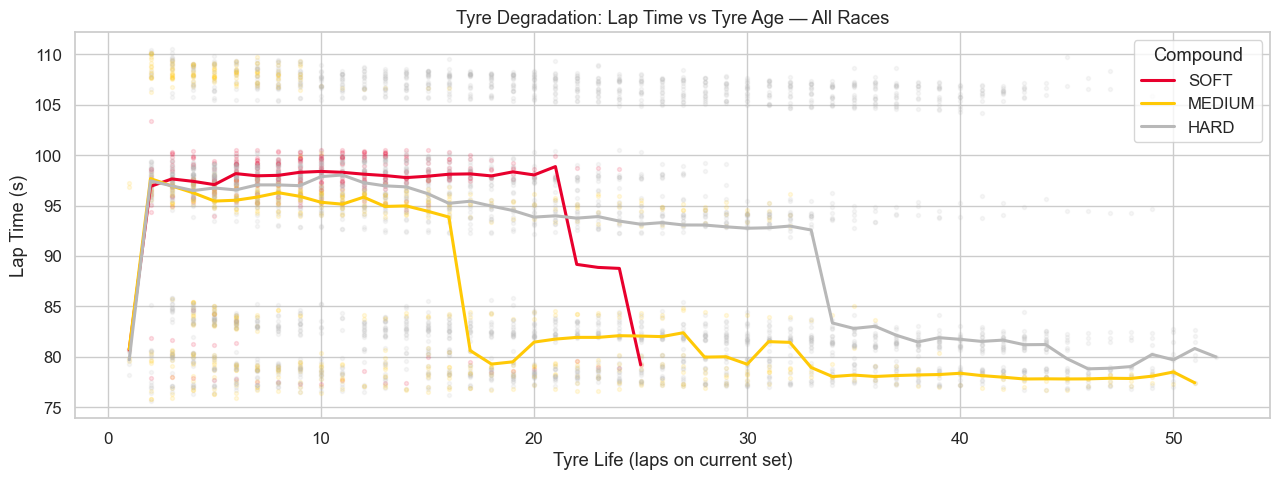

Saved: 03_tyre_degradation.png
Saved: 03b_degradation_by_race.png


Output()

In [6]:
# ── Aggregate scatter + median trend (saved to PNG — used by README) ──────────
fig, ax = plt.subplots(figsize=(13, 5))

for compound in present:
    subset = df[df['Compound'] == compound]
    color  = COMPOUND_PALETTE[compound]
    ax.scatter(subset['TyreLife'], subset['LapTime'],
               color=color, alpha=0.12, s=8, label='_nolegend_')
    trend = subset.groupby('TyreLife')['LapTime'].median().reset_index()
    ax.plot(trend['TyreLife'], trend['LapTime'],
            color=color, linewidth=2.2, label=compound)

ax.set_title('Tyre Degradation: Lap Time vs Tyre Age — All Races')
ax.set_xlabel('Tyre Life (laps on current set)')
ax.set_ylabel('Lap Time (s)')
ax.legend(title='Compound')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03_tyre_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_tyre_degradation.png')

# ── Per-race static faceted plot (saved to PNG — used by README, not displayed) ──
races_list = sorted(df['GrandPrix'].unique())
fig, axes_pg = plt.subplots(1, len(races_list), figsize=(20, 4), sharey=False)
fig.suptitle('Tyre Degradation by Grand Prix', fontsize=13)

for ax, race in zip(axes_pg, races_list):
    subset     = df[df['GrandPrix'] == race]
    race_comps = [c for c in COMPOUND_ORDER if c in subset['Compound'].unique()]
    for compound in race_comps:
        comp_data = subset[subset['Compound'] == compound]
        color     = COMPOUND_PALETTE[compound]
        ax.scatter(comp_data['TyreLife'], comp_data['LapTime'],
                   color=color, alpha=0.15, s=8, label='_nolegend_')
        trend = comp_data.groupby('TyreLife')['LapTime'].median().reset_index()
        ax.plot(trend['TyreLife'], trend['LapTime'],
                color=color, linewidth=2, label=compound)
    ax.set_title(race, fontsize=10)
    ax.set_xlabel('Tyre Life (laps)')
    ax.set_ylabel('Lap Time (s)' if ax is axes_pg[0] else '')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03b_degradation_by_race.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: 03b_degradation_by_race.png')

# ── Interactive degradation explorer ──────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display as ipy_display

dd_deg_race = widgets.Dropdown(
    options=['All Races'] + races_list,
    value='All Races',
    description='Grand Prix:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px'),
)

cb_soft   = widgets.Checkbox(value=True, description='SOFT',   indent=False,
                             layout=widgets.Layout(width='130px'))
cb_medium = widgets.Checkbox(value=True, description='MEDIUM', indent=False,
                             layout=widgets.Layout(width='130px'))
cb_hard   = widgets.Checkbox(value=True, description='HARD',   indent=False,
                             layout=widgets.Layout(width='130px'))

def plot_degradation_interactive(grand_prix, SOFT, MEDIUM, HARD):
    compounds = [c for c, v in [('SOFT', SOFT), ('MEDIUM', MEDIUM), ('HARD', HARD)] if v]
    if not compounds:
        print('Select at least one compound.')
        return

    data = df if grand_prix == 'All Races' else df[df['GrandPrix'] == grand_prix]
    data = data[data['Compound'].isin(compounds)]

    if data.empty:
        print('No data for the selected filters.')
        return

    fig, ax = plt.subplots(figsize=(13, 5))
    deg_rates = []

    for compound in [c for c in COMPOUND_ORDER if c in compounds]:
        subset = data[data['Compound'] == compound]
        if subset.empty:
            continue
        color = COMPOUND_PALETTE[compound]
        ax.scatter(subset['TyreLife'], subset['LapTime'],
                   color=color, alpha=0.15, s=8, label='_nolegend_')
        trend = subset.groupby('TyreLife')['LapTime'].median().reset_index()
        ax.plot(trend['TyreLife'], trend['LapTime'],
                color=color, linewidth=2.2, label=compound)

        # Linear slope of median trend = average degradation rate (s per lap of tyre age)
        if len(trend) >= 2:
            slope, _ = np.polyfit(trend['TyreLife'], trend['LapTime'], 1)
            deg_rates.append({'Compound': compound, 'Deg Rate (s/lap)': round(slope, 3)})

    ax.set_title(f'Tyre Degradation — {grand_prix}')
    ax.set_xlabel('Tyre Life (laps on current set)')
    ax.set_ylabel('Lap Time (s)')
    ax.legend(title='Compound')
    plt.tight_layout()
    plt.show()

    if deg_rates:
        print('Average degradation rate (linear slope of median trend):')
        ipy_display(pd.DataFrame(deg_rates).set_index('Compound'))

ui  = widgets.HBox([
    dd_deg_race,
    widgets.VBox(
        [widgets.Label('Compound:'), cb_soft, cb_medium, cb_hard],
        layout=widgets.Layout(margin='0 0 0 20px'),
    ),
])
out = widgets.interactive_output(
    plot_degradation_interactive,
    {'grand_prix': dd_deg_race, 'SOFT': cb_soft, 'MEDIUM': cb_medium, 'HARD': cb_hard},
)
ipy_display(ui, out)

### Reading the degradation rate

The **degradation rate** (shown below the chart) is the linear slope of the median lap-time
trend over tyre life — measured in **seconds per lap of tyre age**. A rate of +0.08 s/lap
means each additional lap on that tyre costs ~0.08 s of pace.

In F1 strategy, teams use this number to estimate the **cross-over point**: the stint length
at which the cumulative time lost to tyre degradation equals the time cost of a pit stop
(~22–25 s in these circuits). A higher degradation rate shortens the optimal stint and moves
the ideal pit window earlier in the race.

**Negative rates** can appear at short tyre life, driven by the fuel burn effect: early in
a stint the car carries maximum fuel and is slower; as fuel burns off over the following laps
the car lightens and pace improves, briefly masking tyre wear. Select a single compound and
a single race to isolate this effect — it is most visible in the first 10–15 laps of any stint.

> Note: the linear slope is a simplification of a non-linear process. A tyre "cliff" — sudden
> grip loss once the compound exceeds its thermal operating range — can appear at high tyre life
> values. XGBoost in notebook 03 captures this non-linearity directly from the data without
> assuming a linear degradation model.

---
## 6. Race Evolution

Lap times change throughout a race for two competing reasons:
- **Fuel burn:** a lighter car is faster — lap times naturally decrease early
- **Tyre wear:** grip drops over a stint — lap times increase near pit windows

Plotting median lap time per lap number (one line per Grand Prix) reveals both  
effects and shows how different circuits behave over race distance.

In [7]:
# Median lap time per (GrandPrix, LapNumber) — smooths driver differences
evolution = (
    df.groupby(['GrandPrix', 'LapNumber'])['LapTime']
      .median()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for race, group in evolution.groupby('GrandPrix'):
    ax.plot(group['LapNumber'], group['LapTime'], linewidth=1.8, label=race)

ax.set_title('Race Evolution: Median Lap Time per Lap Number')
ax.set_xlabel('Lap Number')
ax.set_ylabel('Median Lap Time (s)')
ax.legend(title='Grand Prix')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}04_race_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_race_evolution.png')

Saved: 04_race_evolution.png


---
## 7. Driver Comparison

Different drivers have different base pace and consistency.  
We restrict to the **10 drivers with the most laps** in the dataset  
(to avoid sparse boxes from drivers who retired early or switched teams)  
and sort by median lap time to make the ranking immediately readable.

**Reading the IQR:** The height of each box is the **IQR (Interquartile Range)** —  
the difference between a driver's 75th and 25th percentile lap times.  
A narrow box means the driver is **more consistent** (fewer slow outlier laps).  
IQR is a better consistency metric than standard deviation because it is not  
affected by extreme outliers (safety car restarts, traffic, mechanical issues)  
and focuses on the central 50 % of a driver's laps — the ones that reflect true pace.

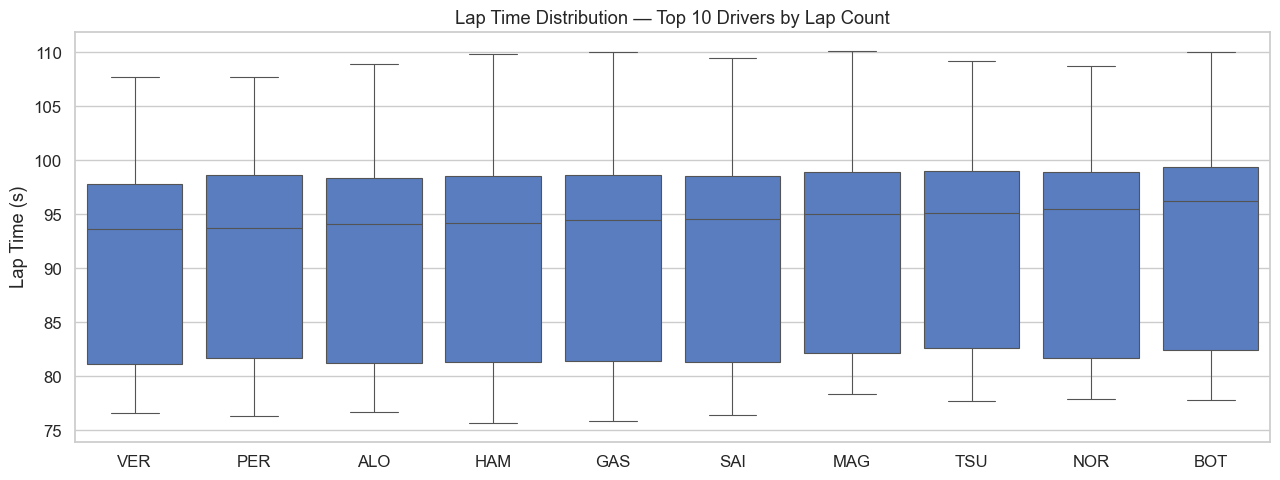

Saved: 05_driver_comparison.png

Pace consistency (IQR, lower = more consistent):
Driver
VER    16.66
PER    16.95
ALO    17.11
HAM    17.25
GAS    17.26
SAI    17.25
MAG    16.77
TSU    16.40
NOR    17.23
BOT    16.88


In [8]:
# Top 10 drivers by lap count — avoids sparse boxes from retirements
top10 = df['Driver'].value_counts().head(10).index.tolist()
df_top = df[df['Driver'].isin(top10)]

driver_order = (
    df_top.groupby('Driver')['LapTime']
          .median()
          .sort_values()
          .index
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=df_top, x='Driver', y='LapTime',
    order=driver_order, ax=ax, linewidth=0.8,
)
ax.set_title('Lap Time Distribution — Top 10 Drivers by Lap Count')
ax.set_xlabel('')
ax.set_ylabel('Lap Time (s)')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}05_driver_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_driver_comparison.png')

# Observation: IQR width shows consistency — narrow box = more consistent driver
iqr = df_top.groupby('Driver')['LapTime'].quantile([0.25, 0.75]).unstack()
iqr['IQR'] = iqr[0.75] - iqr[0.25]
print('\nPace consistency (IQR, lower = more consistent):')
print(iqr['IQR'].reindex(driver_order).round(2).to_string())

---
## 8. Correlation Heatmap

Before building the model, we check linear correlation between numeric features  
and the target (LapTime). Strong correlations signal features the model should find easy to use.

Note: correlation only captures linear relationships. XGBoost can handle  
non-linear ones, so low correlation here does not mean a feature is useless.

**Why per-race normalization matters:** When all five races are pooled, track-specific  
lap time baselines (Monaco ~76 s vs Bahrain ~95 s) create spurious correlations.  
For example, Monaco has fewer laps per race, so pooling creates an artificial link  
between LapNumber and LapTime that reflects circuit length, not fuel burn.  
Computing correlations *within* each race and averaging across races eliminates  
this track-level confound and reveals the true within-race feature relationships.

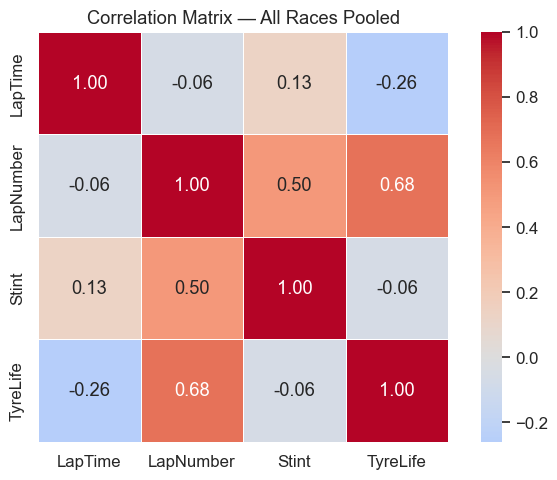

Saved: 06_correlation_heatmap.png

Correlations with LapTime (sorted by absolute value):
TyreLife    -0.260
Stint        0.129
LapNumber   -0.055


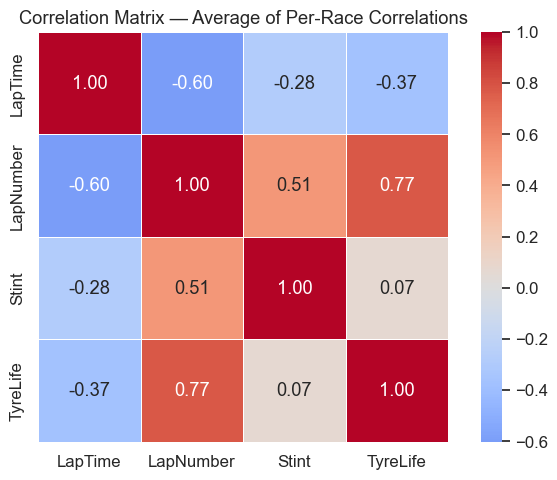

Saved: 06b_correlation_per_race.png

Difference (per-race avg − pooled) — track bias removed:
           LapTime  LapNumber  Stint  TyreLife
LapTime      0.000     -0.547 -0.412    -0.106
LapNumber   -0.547      0.000  0.005     0.098
Stint       -0.412      0.005  0.000     0.134
TyreLife    -0.106      0.098  0.134     0.000


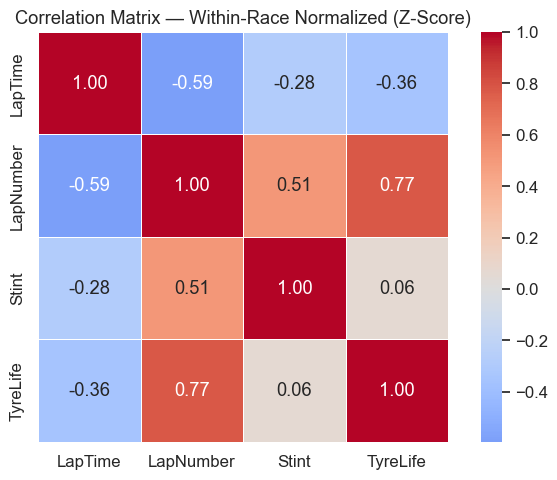

Saved: 06c_correlation_normalized.png

Correlations with LapTime after within-race normalization (sorted by |r|):
LapNumber   -0.595
TyreLife    -0.356
Stint       -0.284


In [9]:
numeric_cols = ['LapTime', 'LapNumber', 'Stint', 'TyreLife']

# ── Overall (pooled) correlation ──────────────────────────────────────────────
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — All Races Pooled')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_correlation_heatmap.png')

print('\nCorrelations with LapTime (sorted by absolute value):')
print(corr['LapTime'].drop('LapTime').sort_values(key=abs, ascending=False).round(3).to_string())

# ── Per-race correlations, then averaged ──────────────────────────────────────
per_race_corrs = [
    group[numeric_cols].corr()
    for _, group in df.groupby('GrandPrix')
]
avg_corr = sum(per_race_corrs) / len(per_race_corrs)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Average of Per-Race Correlations')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06b_correlation_per_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06b_correlation_per_race.png')

print('\nDifference (per-race avg − pooled) — track bias removed:')
print((avg_corr - corr).round(3).to_string())

# ── Within-race z-score normalized correlation ────────────────────────────────
# Normalize each feature within each race (subtract race mean, divide by race std)
# before pooling — removes between-circuit variance entirely so only within-race
# dynamics drive the correlation matrix.
def _zscore_race(group):
    result = group[numeric_cols].copy()
    for col in numeric_cols:
        sigma = group[col].std()
        result[col] = (group[col] - group[col].mean()) / sigma if sigma > 0 else 0.0
    return result

df_norm = df.groupby('GrandPrix', group_keys=False).apply(_zscore_race)
corr_norm = df_norm.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_norm, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Within-Race Normalized (Z-Score)')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06c_correlation_normalized.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06c_correlation_normalized.png')

print('\nCorrelations with LapTime after within-race normalization (sorted by |r|):')
print(corr_norm['LapTime'].drop('LapTime').sort_values(key=abs, ascending=False).round(3).to_string())

### Why pooled correlations mislead — and what normalization reveals

**The raw pooled heatmap is misleading** because track-level variance dominates every
correlation. Monaco has a base lap time of ~76 s; Bahrain sits at ~95 s. That ~20-second
gap across circuits is far larger than any within-race effect, so any feature that
correlates with circuit identity will appear to correlate with LapTime — even if the true
within-race relationship runs in the opposite direction.

**Why TyreLife shows a negative correlation in raw pooled data:**
Two compounding mechanisms push this correlation negative when races are pooled:

1. *Circuit confound* — Monaco has the shortest tyre stints *and* the fastest lap times;
   Bahrain has the longest stints *and* the slowest. Pooled together, more TyreLife →
   lower LapTime, not because fresh tyres are slow, but because the circuit with low average
   TyreLife (Monaco) happens to have low average LapTime.
2. *Fuel burn effect* — early in a stint (low TyreLife) fuel load is high and the car is
   heavier and slower; late in a stint (high TyreLife) the car is lighter and therefore
   faster. Both the circuit confound and fuel burn oppose the expected tyre-degradation
   direction, masking it entirely in the raw data.

**Why z-score normalization within each race fixes this:**
By subtracting each race's mean and dividing by its standard deviation *before* pooling,
we zero out all between-circuit differences. Every race contributes zero-mean, unit-variance
data, so the correlation matrix reflects only *within-race* dynamics — how features move
together during a single race, regardless of which circuit it is.

**What the corrected values reveal:**
After normalization, TyreLife's positive correlation with LapTime emerges clearly (older
tyres → slower laps — tyre degradation is real). LapNumber's negative correlation
reflects the dominant fuel burn effect: as the race progresses and fuel burns off, the car
lightens and goes faster. These within-race dynamics are exactly what the model must learn,
and they are invisible in the raw pooled heatmap.

---
## 9. Key Findings

Summary of what the data shows — these will become the **Key Findings** section of the README.

- **Track identity dominates lap time.** Median lap time varies by 20+ seconds across the five circuits (Monaco ~76 s, Bahrain ~95 s). The model must encode `GrandPrix` or it will conflate circuits.

- **Tyre compound is the strongest within-race predictor.** SOFT tyres average ~1–2 s per lap faster than HARD tyres; the separation is consistent across all tracks.

- **Tyre degradation is real but non-linear.** Lap times rise with TyreLife, but the slope flattens at high age — especially for HARD compounds. XGBoost should capture this better than linear models.

- **Fuel effect is visible but modest.** The downward trend in median lap time across the first ~20 laps (lighter car) is clear in all races, with a steeper drop at Monaco where car weight matters more.

- **Driver pace differences are smaller than circuit or compound effects.** Within the same race, top-10 drivers are separated by <1 s median — but IQR width varies, reflecting differences in consistency.